In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. BUILD WORKING MODEL
### Load real dataset

In [5]:
data = load_iris()
X = data.data
y = data.target

In [13]:
print("Dataset: ", X.shape)
print("Classes: ", data.target_names)
#print("First 5 rows:\n", X[:5])
#print(data)


Dataset:  (150, 4)
Classes:  ['setosa' 'versicolor' 'virginica']


### Split data into TRAINING and TESTING

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 120
Testing samples:  30


### Train your model
#### A Decision Tree learns rules like:
#### "If petal length > 2.5 cm AND petal width < 1.8 cm → versicolor"

In [15]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


### Evaluate your model

In [17]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.1f}%")

Accuracy: 100.0%


### Confusion Matrix

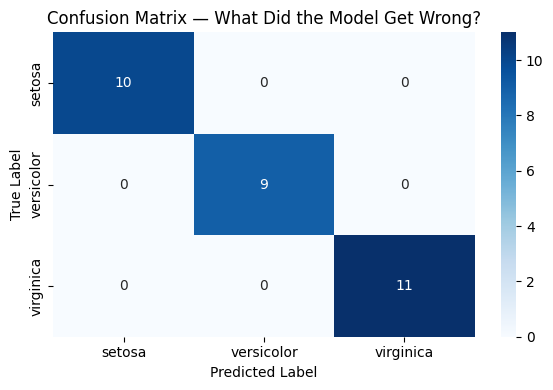

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            cmap='Blues')
plt.title('Confusion Matrix — What Did the Model Get Wrong?')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 2. MAKE IT FAIL ON PURPOSE

### Experiment A - Training in too little data

In [20]:
X_tiny, _, y_tiny, _ = train_test_split(X, y, train_size=5, random_state=42)

tiny_model = DecisionTreeClassifier(random_state=42)
tiny_model.fit(X_tiny, y_tiny)

y_tiny_pred = tiny_model.predict(X_test)
tiny_accuracy = accuracy_score(y_test, y_tiny_pred)

print(f"Accuracy with 5 training samples: {tiny_accuracy * 100:.1f}%")
print(f"Accuracy with 120 training samples: {accuracy * 100:.1f}%")
print(f"\nConclusion: Data size matters more than algorithm choice.")

Accuracy with 5 training samples: 80.0%
Accuracy with 120 training samples: 100.0%

Conclusion: Data size matters more than algorithm choice.


### Experiment B - OVERFITTING

### Overfitting
### - a model that is too deep memorizes training data but fails on new data

In [23]:
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
limited_model = DecisionTreeClassifier(max_depth=3, random_state=42)

overfit_model.fit(X_train, y_train)
limited_model.fit(X_train, y_train)

# Compare performance ON TRAINING DATA vs TEST DATA
print("=== Overfit Model (no depth limit) ===")
print(f"  Train accuracy: {accuracy_score(y_train, overfit_model.predict(X_train))*100:.1f}%")
print(f"  Test accuracy:  {accuracy_score(y_test, overfit_model.predict(X_test))*100:.1f}%")

print("\n=== Constrained Model (max depth=3) ===")
print(f"  Train accuracy: {accuracy_score(y_train, limited_model.predict(X_train))*100:.1f}%")
print(f"  Test accuracy:  {accuracy_score(y_test, limited_model.predict(X_test))*100:.1f}%")

print("\n→ When train accuracy >> test accuracy = OVERFITTING")
print("→ The model memorized the training data instead of learning patterns")

=== Overfit Model (no depth limit) ===
  Train accuracy: 100.0%
  Test accuracy:  100.0%

=== Constrained Model (max depth=3) ===
  Train accuracy: 95.8%
  Test accuracy:  100.0%

→ When train accuracy >> test accuracy = OVERFITTING
→ The model memorized the training data instead of learning patterns


### Experiment C - Predict on a brand new flower

In [25]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = model.predict(new_flower)
probability = model.predict_proba(new_flower)

print(f"Predicted species: {data.target_names[prediction[0]]}")
print(f"Confidence: {probability[0].max()*100:.1f}%")
print(f"Full probability breakdown: {dict(zip(data.target_names, probability[0].round(2)))}")

Predicted species: setosa
Confidence: 100.0%
Full probability breakdown: {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}


### QUESTIONS

### MY UNDERSTANDING CHECK (write your answers here):

#### Q1: Why do we split data into train and test sets?
#### Answer: To simulate the effectivity of the data for its purpose.
#### Correct Answer: To simulate "new data the model has never seen" — real world performance

#### Q2: What is overfitting in your own words?
#### Answer: Overfitting is memorizing training data but not learning patterns and failed to perform in real world scenario.

#### Q3: If my test accuracy is 60% but train accuracy is 99%, what's wrong?
#### Answer: The training data might be overfitting.
#### Correct Answer: Severe overfitting — the model learned the training set, not the underlying pattern.